# Transformer Models — Attention-Based Architectures

This section uses a small Transformer Encoder style model with self-attention for binary text classification.

The final result is compared with previous Vanilla RNN, LSTM, and GRU results if they are available.

TensorFlow/Keras is used because it matches the previous deep learning sections and gives simple high-level neural network layers.

## Imports and Reproducibility

First we import the libraries and set random seeds so the result is more stable.

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("default")

## Loading the Dataset

We use the Keras IMDB reviews dataset. It is public and does not need Kaggle credentials.

In [2]:
max_words = 10000
max_len = 200
embedding_dim = 64

num_heads = 2
ff_dim = 64
dropout_rate = 0.2
batch_size = 64
epochs = 10

# These limits keep the notebook fast in VS Code and Colab.
max_train_samples = 12000
max_test_samples = 5000
validation_size = 5000

previous_data_names = ["x_train", "y_train", "x_val", "y_val", "x_test", "y_test"]
has_previous_processed_data = all(name in globals() for name in previous_data_names)

if has_previous_processed_data:
    print("Using previous processed train/validation/test data.")
else:
    (raw_train, y_train_full), (raw_test, y_test_full) = imdb.load_data(num_words=max_words)
    y_train_full = np.array(y_train_full).astype("int32")
    y_test_full = np.array(y_test_full).astype("int32")
    print("Loaded IMDB dataset from Keras.")

print("Previous processed data found:", has_previous_processed_data)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


d:\SHARIF\TERM7\DATA\HW1\.venv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Loaded IMDB dataset from Keras.
Previous processed data found: False


## Quick EDA

Now we look at the shape, a few reviews, labels, null values, and review lengths.

In [3]:
def decode_review(sequence):
    word_index = imdb.get_word_index()
    reverse_word_index = {value + 3: key for key, value in word_index.items()}
    reverse_word_index[0] = "<PAD>"
    reverse_word_index[1] = "<START>"
    reverse_word_index[2] = "<UNK>"
    reverse_word_index[3] = "<UNUSED>"
    return " ".join(reverse_word_index.get(i, "?") for i in sequence)


if has_previous_processed_data:
    X_train_preview = np.array(x_train)
    y_train_preview = np.array(y_train)
    lengths = np.count_nonzero(X_train_preview, axis=1)
    eda_df = pd.DataFrame({
        "text": ["Previous preprocessed data was reused. Raw text is not available."],
        "label": [int(y_train_preview[0])],
    })
    print("Train shape:", X_train_preview.shape)
    print("Validation shape:", np.array(x_val).shape)
    print("Test shape:", np.array(x_test).shape)
else:
    lengths = [len(review) for review in raw_train]
    sample_texts = [decode_review(review) for review in raw_train[:5]]
    eda_df = pd.DataFrame({"text": sample_texts, "label": y_train_full[:5]})
    print("Raw train reviews:", len(raw_train))
    print("Raw test reviews:", len(raw_test))

display(eda_df)
print("Null values:")
display(eda_df.isnull().sum())

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
Raw train reviews: 25000
Raw test reviews: 25000


,text,label
0,<START> this film was just brilliant casting l...,1
1,<START> big hair big boobs bad music and a gia...,0
2,<START> this has to be one of the worst films ...,0
3,<START> the <UNK> <UNK> at storytelling the tr...,1
4,<START> worst mistake of my life br br i picke...,0


Null values:


text     0
label    0
dtype: int64

,count
label,
0,12500
1,12500


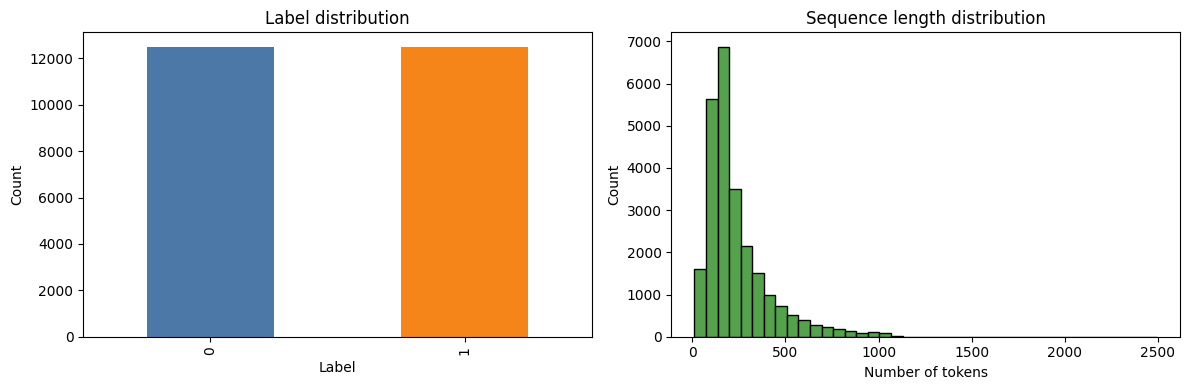

In [4]:
if has_previous_processed_data:
    label_counts = pd.Series(y_train_preview, name="label").value_counts().sort_index()
else:
    label_counts = pd.Series(y_train_full, name="label").value_counts().sort_index()

display(label_counts.to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_counts.plot(kind="bar", ax=axes[0], color=["#4c78a8", "#f58518"])
axes[0].set_title("Label distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

axes[1].hist(lengths, bins=40, color="#54a24b", edgecolor="black")
axes[1].set_title("Sequence length distribution")
axes[1].set_xlabel("Number of tokens")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Data Preprocessing

The IMDB labels are already binary integers. We only pad or truncate each review to the same length.

In [5]:
if has_previous_processed_data:
    X_train = np.array(x_train).astype("int32")
    y_train = np.array(y_train).astype("int32")
    X_val = np.array(x_val).astype("int32")
    y_val = np.array(y_val).astype("int32")
    X_test = np.array(x_test).astype("int32")
    y_test = np.array(y_test).astype("int32")
else:
    X_train_all = pad_sequences(raw_train, maxlen=max_len, padding="post", truncating="post")
    X_test_all = pad_sequences(raw_test, maxlen=max_len, padding="post", truncating="post")

    X_train = X_train_all[:max_train_samples]
    y_train = y_train_full[:max_train_samples]
    X_val = X_train_all[-validation_size:]
    y_val = y_train_full[-validation_size:]
    X_test = X_test_all[:max_test_samples]
    y_test = y_test_full[:max_test_samples]

max_len = X_train.shape[1]
vocab_size = max(max_words, int(max(X_train.max(), X_val.max(), X_test.max())) + 1)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("Vocabulary size used by the model:", vocab_size)

X_train: (12000, 200) y_train: (12000,)
X_val: (5000, 200) y_val: (5000,)
X_test: (5000, 200) y_test: (5000,)
Vocabulary size used by the model: 10000


## Transformer Encoder Model

The model uses token embeddings, positional embeddings, multi-head self-attention, normalization, a feed-forward block, dropout, pooling, and a sigmoid output.

In [6]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions


class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.2):
        super().__init__()
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attention_output = self.attention(inputs, inputs)
        attention_output = self.dropout1(attention_output, training=training)
        out1 = self.layernorm1(inputs + attention_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [7]:
def build_transformer_model(
    vocab_size=vocab_size,
    max_len=max_len,
    embed_dim=embedding_dim,
    num_heads=num_heads,
    ff_dim=ff_dim,
    dropout_rate=dropout_rate,
):
    inputs = keras.Input(shape=(max_len,), dtype="int32")
    x = TokenAndPositionEmbedding(max_len, vocab_size, embed_dim)(inputs)
    x = TransformerEncoder(embed_dim, num_heads, ff_dim, dropout_rate)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="small_transformer_encoder")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


transformer_model = build_transformer_model()
transformer_model.summary()

Model: "small_transformer_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 200, 64)        │       652,800 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 200, 64)        │        41,792 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 696,705 (2.66 MB)

 Trainable params: 696,705 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

## Training

Early stopping stops training when validation loss does not improve.

In [9]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=10, batch_size=64):
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1,
    )
    return history


history = train_model(
    transformer_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=epochs,
    batch_size=batch_size,
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 69ms/step - accuracy: 0.9341 - loss: 0.1756 - val_accuracy: 0.8562 - val_loss: 0.4440
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.9532 - loss: 0.1352 - val_accuracy: 0.8544 - val_loss: 0.4531
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.9643 - loss: 0.1041 - val_accuracy: 0.8490 - val_loss: 0.5457
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9732 - loss: 0.0841 - val_accuracy: 0.8446 - val_loss: 0.6847
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.9740 - loss: 0.0811 - val_accuracy: 0.8422 - val_loss: 0.7392
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 64ms/step - accuracy: 0.9793 - loss: 0.0591 - val_accuracy: 0.8276 - val_loss: 0.8224


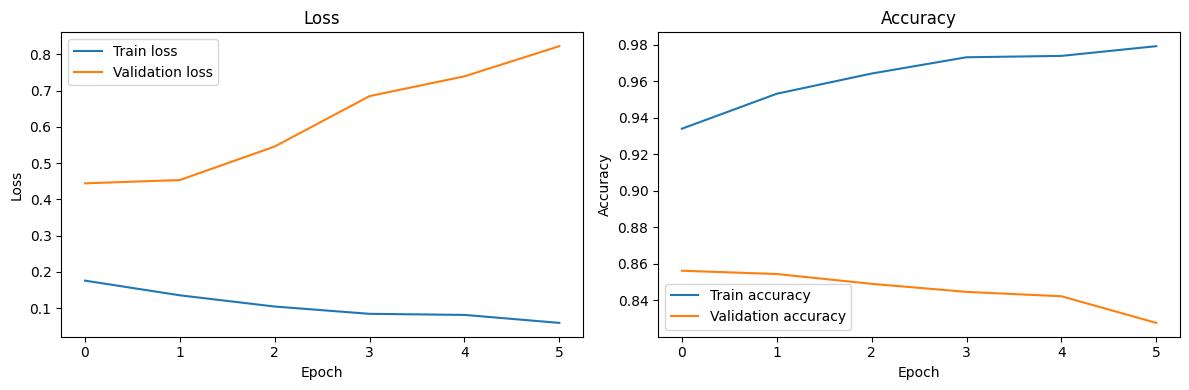

In [10]:
def plot_history(history):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["loss"], label="Train loss")
    axes[0].plot(history_df["val_loss"], label="Validation loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_df["accuracy"], label="Train accuracy")
    axes[1].plot(history_df["val_accuracy"], label="Validation accuracy")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_history(history)

## Evaluation

We evaluate the Transformer on the test set with accuracy, precision, recall, F1-score, confusion matrix, and classification report.

,Test Accuracy,Keras Test Accuracy,Precision,Recall,F1-score
0,0.8402,0.8402,0.800516,0.893783,0.844583


Classification report:
              precision    recall  f1-score   support

    Negative       0.89      0.79      0.84      2571
    Positive       0.80      0.89      0.84      2429

    accuracy                           0.84      5000
   macro avg       0.84      0.84      0.84      5000
weighted avg       0.85      0.84      0.84      5000



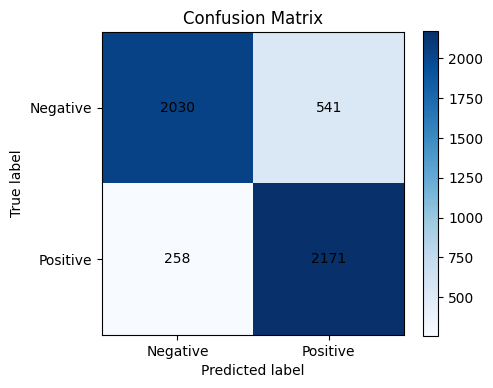

In [11]:
def evaluate_classification_model(model, X_test, y_test, batch_size=64):
    test_loss, test_accuracy = model.evaluate(X_test, y_test, batch_size=batch_size, verbose=0)
    y_proba = model.predict(X_test, batch_size=batch_size, verbose=0).ravel()
    y_pred = (y_proba >= 0.5).astype("int32")

    results = {
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Keras Test Accuracy": test_accuracy,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
    }

    display(pd.DataFrame([results]))
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"], zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["Negative", "Positive"])
    plt.yticks([0, 1], ["Negative", "Positive"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

    return results, y_pred, y_proba


transformer_results, y_pred_transformer, y_proba_transformer = evaluate_classification_model(
    transformer_model,
    X_test,
    y_test,
    batch_size=batch_size,
)

## Comparison with Previous RNN/LSTM Results


In [13]:
if "rnn_results_df" in globals():
    comparison_df = rnn_results_df.copy()
elif "results_df" in globals():
    comparison_df = results_df.copy()
else:
    comparison_df = pd.DataFrame({
        "Model": ["Vanilla RNN", "LSTM", "GRU"],
        "Test Accuracy": ["0.733833", "0.808167", "0.785333"],
        "F1-score": ["0.727985", "0.807493", "0.772679"],
        "Notes": [
            "From previous RNN section",
            "From previous RNN section",
            "From previous RNN section",
        ],
    })

transformer_row = pd.DataFrame({
    "Model": ["Transformer Encoder"],
    "Test Accuracy": [transformer_results["Test Accuracy"]],
    "F1-score": [transformer_results["F1-score"]],
    "Notes": ["This section"],
})

comparison_df = comparison_df[comparison_df["Model"] != "Transformer Encoder"]
comparison_df = pd.concat([comparison_df, transformer_row], ignore_index=True)
display(comparison_df)

,Model,Test Accuracy,F1-score,Notes
0,Vanilla RNN,0.733833,0.727985,From previous RNN section
1,LSTM,0.808167,0.807493,From previous RNN section
2,GRU,0.785333,0.772679,From previous RNN section
3,Transformer Encoder,0.8402,0.844583,This section


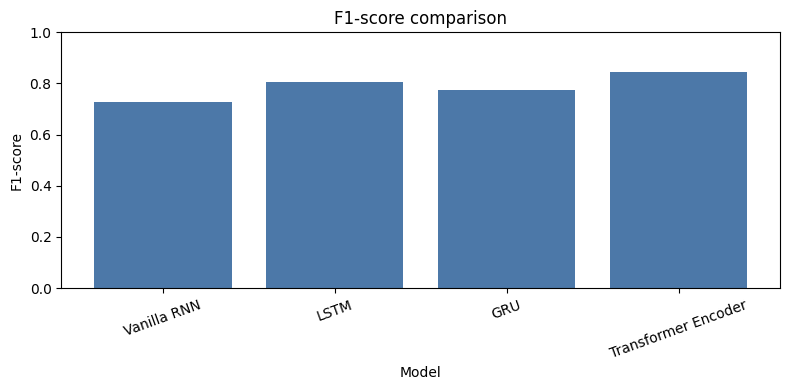

In [14]:
plot_df = comparison_df.copy()
plot_df["F1_numeric"] = pd.to_numeric(plot_df["F1-score"], errors="coerce")
plot_ready = plot_df.dropna(subset=["F1_numeric"])

plt.figure(figsize=(8, 4))
plt.bar(plot_ready["Model"], plot_ready["F1_numeric"], color="#4c78a8")
plt.title("F1-score comparison")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Discussion Questions

**What are the main advantages and disadvantages of Transformer-based models?**

Transformers can learn important relations between far apart words and they train well in parallel. Their main disadvantage is that they need more memory, more computation, and more data than simpler models.

**Why do Transformers scale well with data and model size?**

They use attention and parallel computation, so larger models can learn many patterns from large datasets. More layers, heads, and data often improve their representations.

**Why do they often require more computational resources than simpler models?**

Self-attention compares tokens with many other tokens in the sequence. This creates more calculations and uses more memory, especially for long text.

**What is self-attention, and what problem does it solve?**

Self-attention lets each word look at other words in the same text and decide which ones are important. It helps the model understand context better.

**Why can attention model long-range dependencies better than simple RNNs?**

In attention, two far words can connect directly. In a simple RNN, information must pass step by step, so long-range information can become weak.

**What is multi-head attention, and why does it help?**

Multi-head attention runs several attention operations at the same time. Each head can focus on different word relations, so the model gets richer information.

**What is the role of positional encoding?**

Attention alone does not know word order. Positional encoding adds position information so the model can understand where each token appears in the sequence.